# Introduction

The telecommunications industry operates in a saturated, highly competitive market where product differentiation is minimal and customer switching costs are low. In this environment, retaining existing customers is both more cost-effective and strategically critical than acquiring new ones. Business intelligence and data mining have consequently become essential tools, enabling organisations to move beyond reactive decision-making by identifying patterns in customer behaviour before problems escalate.

This project focuses on the problem of **customer churn**. The rate at which customers discontinue their subscription to a telecom service. By analysing a real-world dataset of US telecom customers, this study aims to identify the key drivers of churn and develop predictive models that allow the business to intervene before customers leave.

---

# Business Problem

The central business problem is the high rate of customer attrition faced by telecom providers. Given that acquiring a new customer costs significantly more than retaining an existing one, identifying at-risk customers early represents a clear commercial opportunity. The guiding question for this project is:

> *"Which key factors contribute most to customer churn, and which predictive model can most accurately identify at-risk customers before they leave?"*

**Dataset Justification**

The selected dataset covers a US telecom company's customer base with a focus on California, comprising 33 variables across customer demographics, service usage, and financial behaviour. It is well-suited to this analysis for three reasons. First, it includes a binary churn label suitable for supervised classification. Second, it contains qualitative churn reasons enabling root-cause analysis beyond simple prediction. Third, financial variables such as Monthly Charges, Total Charges, and Customer Lifetime Value (CLTV) allow assessment of the financial impact of attrition and the potential return on investment of retention campaigns.

---

# Research Questions

**Primary Question:**
*"Can machine learning models accurately predict customer churn in a telecommunications company, and which factors most strongly influence a customer's likelihood of leaving?"*

**Secondary Questions:**

1. Which customer characteristics are most strongly associated with churn? Analysing demographics, service usage, and financial variables will reveal patterns distinguishing customers who stay from those who leave.
2. How do contract type and service package influence customer loyalty? Understanding this relationship may inform more effective subscription model design.
3. Which machine learning model provides the most accurate churn predictions? Logistic Regression, Decision Tree, and KNN will be evaluated using accuracy, precision, recall, and F1-score.
4. How can predictive insights be translated into actionable business strategies? The ultimate goal is to produce recommendations that reduce revenue loss and improve retention.

---

# Business Context

Telecom providers face few barriers to customer switching, making proactive retention essential. Data mining and predictive analytics address this by identifying early warning signs of dissatisfaction, enabling targeted intervention before customers leave.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("data/Telco_customer_churn.csv")

# Stage 2: Exploratory Data Analysis & Pre-Processing of Telco Customer Churn

### Group 11: Tai Jing, Kael Maliq, Ayan Ahmad, Muhammad Pratama

**Objective:** Explore data quality, visualise patterns, and prepare the dataset for modelling.

### Univariate Analysis : initial exploration of data.


**Customer Churn Distribution**

A bar chart of the Churn Label was used to assess the scale of customer attrition. The results show a 27% churn rate, confirming that churn is a significant business issue, as losing customers directly impacts revenue and increases acquisition costs.

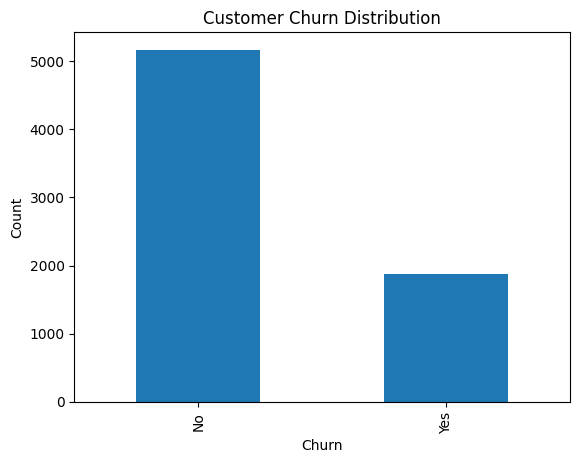

In [3]:
df["Churn Label"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

The distribution also reveals a class imbalance, an important point for modelling as it can bias predictions toward the majority class meaning churners may be under-detected. This step was necessary to highlight business risk and inform further modelling decisions, particularly around handling imbalance.

A histogram of Tenure Months was used to indicate customer loyalty, with longer relationships typically associated with lower churn risk (Krautz and Hoffmann, 2017). 

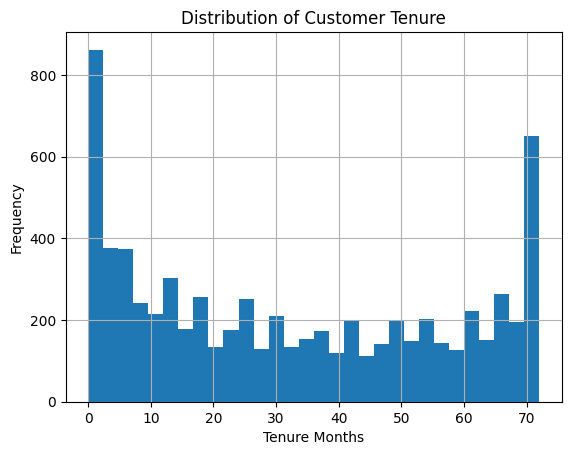

In [4]:
df["Tenure Months"].hist(bins=30)
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure Months")
plt.ylabel("Frequency")
plt.show()

The distribution shows a higher concentration of short-tenure customers suggesting a larger at-risk segment early in the customer lifecycle. This highlight a critical point for intervention where retention strategies can be most effective.

**Pricing** is examined after tenure, as cost is a common driver of early churn.

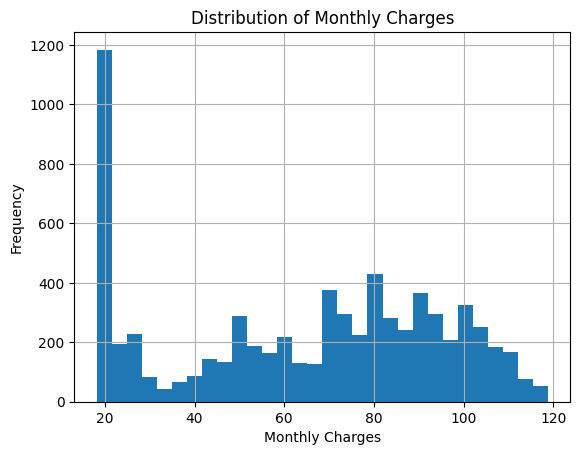

In [5]:
df["Monthly Charges"].hist(bins=30)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

Based on the histogram, monthly charges vary across the customer base showing different service tiers. This variation suggests differing levels of price sensitivity, making it a relevant variable for understanding churn behaviour. To better understand the spread of price, a box plot is examined below. 

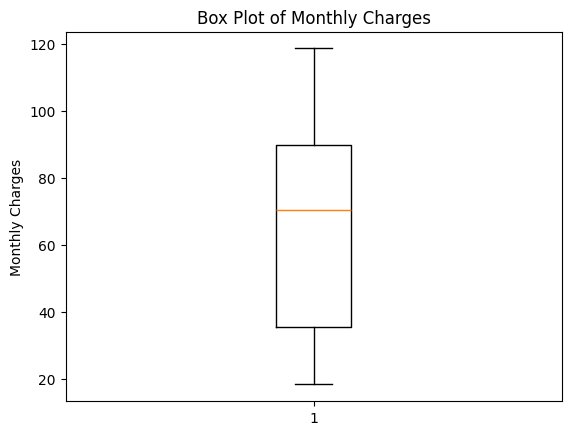

In [6]:
plt.boxplot(df["Monthly Charges"])

plt.title("Box Plot of Monthly Charges")
plt.ylabel("Monthly Charges")

plt.show()

The box plot confirms substantial pricing variation. The middle 50% pay between £35–£90 per month. This highlights meaningful differences in what customers pay, which may influence perceived value and satisfaction. Having examined individual variables, cumulative spend is examined next.

In [7]:
# convert Total Charges to numeric
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

# check data types
df.dtypes

CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges        float64
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object

In [1]:
df["Total Charges"].dropna().hist(bins=30)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Frequency")

plt.show()

NameError: name 'df' is not defined

Building on pricing and tenure, total charges are examined as a measure of cumulative customer value. The right-skewed distribution indicates that many customers contribute low overall value, mainly due to shorter tenure. From a business perspective, this **highlights** the impact of early churn on lost lifetime value. Having explored individual variables, the following section examines how they relate directly to churn outcomes.

## Bivariate / Multivariate Analysis

The univariate analysis established the distribution of key variables. The following section now examines how those variables relate directly to churn, identifying the factors most strongly associated with customer attrition.

**Churn by Contract Type.**

Churn Label       No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


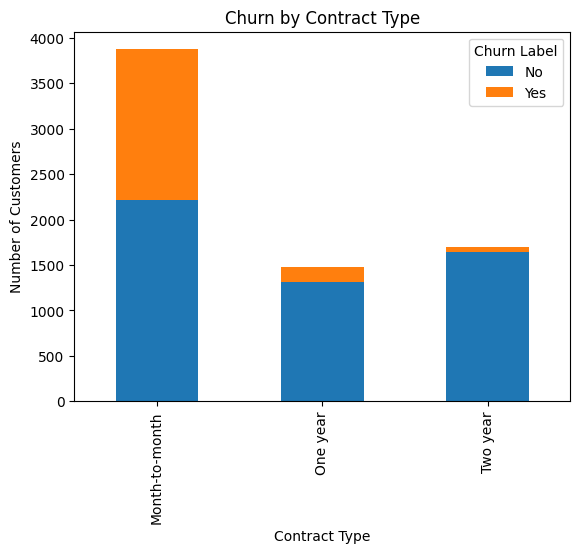

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# churn vs contract
contract_churn = pd.crosstab(df["Contract"], df["Churn Label"])

print(contract_churn)

contract_churn.plot(kind="bar", stacked=True)
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

Contract type is analysed against churn to identify behavioural differences across customer agreements. Customers on month-to-month contracts show significantly higher churn rates compared to those on longer contract terms. This suggests that lack of commitment increases churn risk, making contract type a strong predictor of customer churn.

**Churn by Payment Method.**

Churn Label                  No   Yes
Payment Method                       
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308


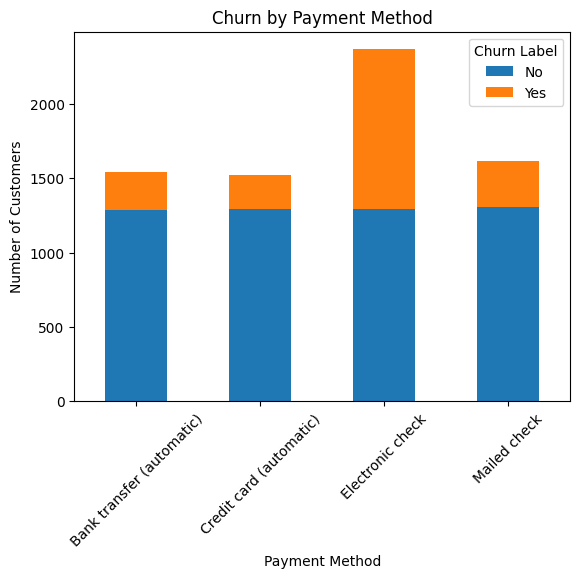

In [13]:
payment_churn = pd.crosstab(df["Payment Method"], df["Churn Label"])

print(payment_churn)

payment_churn.plot(kind="bar", stacked=True)
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

Following contract type, payment method is examined as it reflects customer engagement and billing behaviour. Customers using electronic check show notably higher churn compared to those on automated payment methods, suggesting automated payments may be associated with stronger commitment. As a result, payment method serves a useful behavioural indicator for the business.

**Churn by Internet Service.**

Churn Label         No   Yes
Internet Service            
DSL               1962   459
Fiber optic       1799  1297
No                1413   113


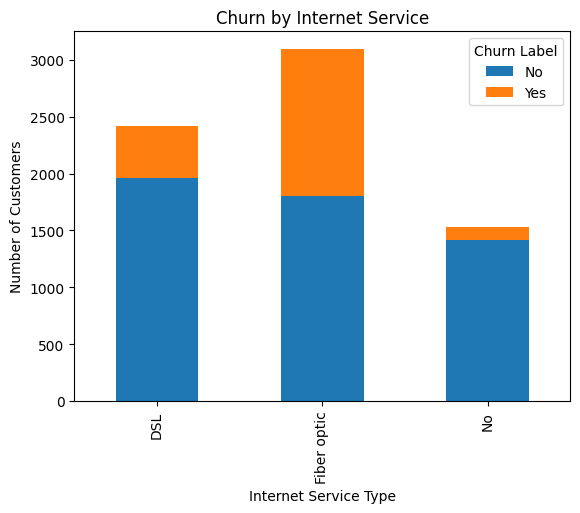

In [14]:
internet_churn = pd.crosstab(df["Internet Service"], df["Churn Label"])

print(internet_churn)

internet_churn.plot(kind="bar", stacked=True)
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service Type")
plt.ylabel("Number of Customers")
plt.show()

Internet service type is then examined to assess whether service quality or offering influences churn. Fibre optic customers show higher churn rates suggesting potential dissatisfaction with preceived value at that price point. This indicates that lower-paying customers may be receiving proportional value, and highlights a need for the business to consider pricing strategy or service improvement adjustments. 

**10. Bivariate Scatter Analysis — Numerical Variables vs Churn**

The bar charts above examined categorical variables in isolation. To further investigate these patterns, the following analysis examines how key numerical variables interact with churn. Three pairs are selected, as scatter plots are only meaningful for continuous numerical variables, of which tenure, monthly charges, and total charges are the only three in this dataset.

- **Tenure vs Monthly Charges:** Tests whether short-tenure, high-charge customers form a distinct churn cluster.
- **Tenure vs Total Charges:** Reveals whether low-value customers churn disproportionately.
- **Monthly Charges vs Total Charges:** Identifies customers with high monthly fees but low total spend.

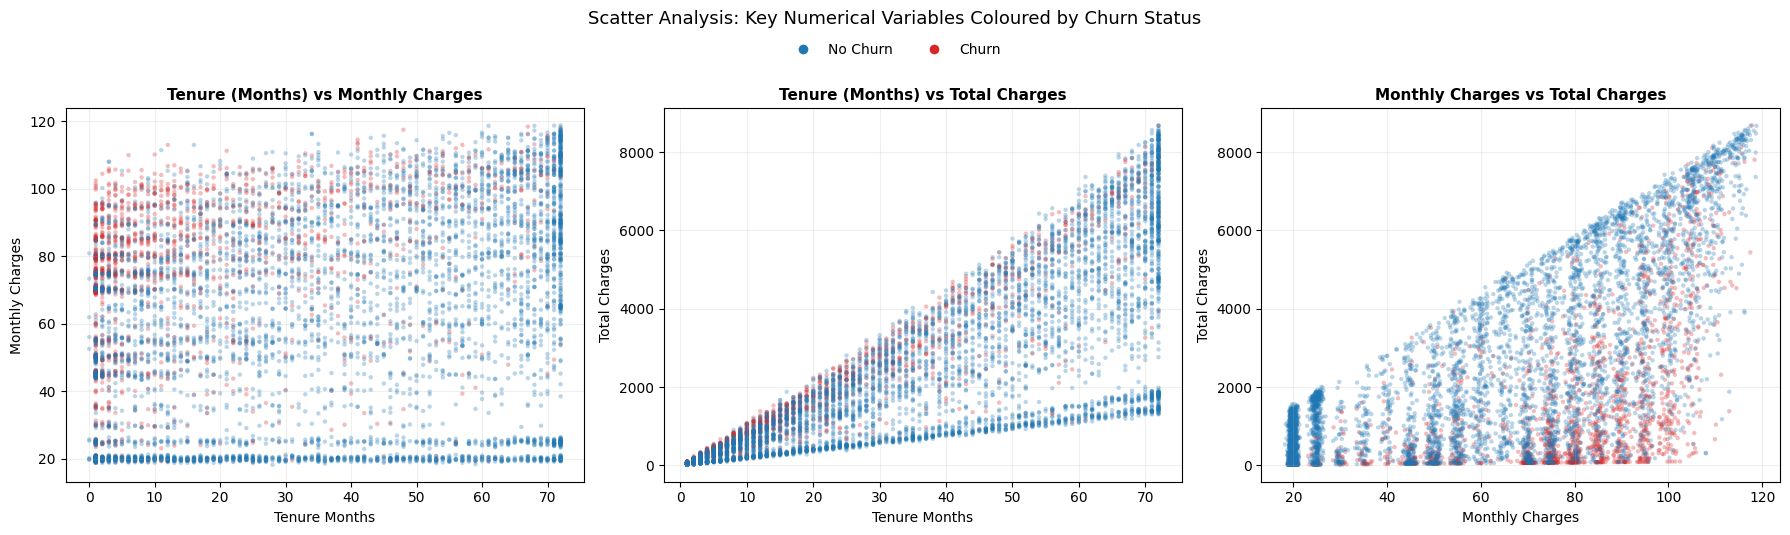

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Define churn colours — red for churned, blue for stayed
# Using the already-encoded Churn Label (0 = No, 1 = Yes)
churn_col = df['Churn Label'].map({'No': '#1f77b4', 'Yes': '#d62728'})

scatter_pairs = [
    ('Tenure Months',   'Monthly Charges', 'Tenure (Months) vs Monthly Charges'),
    ('Tenure Months',   'Total Charges',   'Tenure (Months) vs Total Charges'),
    ('Monthly Charges', 'Total Charges',   'Monthly Charges vs Total Charges'),
]

for ax, (x_col, y_col, title) in zip(axes, scatter_pairs):
    ax.scatter(
        df[x_col], df[y_col],
        c=churn_col,
        alpha=0.3,       # transparency reveals density in overlapping regions
        s=10,            # small point size keeps dense areas readable
        edgecolors='none'
    )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(x_col, fontsize=10)
    ax.set_ylabel(y_col, fontsize=10)
    ax.grid(alpha=0.2)

# Shared legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', markersize=8, label='No Churn'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728', markersize=8, label='Churn'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=2,
           bbox_to_anchor=(0.5, 1.02), fontsize=10, frameon=False)

plt.suptitle('Scatter Analysis: Key Numerical Variables Coloured by Churn Status',
             fontsize=13, y=1.06)
plt.tight_layout()
plt.savefig('scatter_churn.png', dpi=150, bbox_inches='tight')
plt.show()

The **Tenure vs Monthly Charges** plot shows churners concentrated toward shorter tenure values, confirming tenure as a protective factor, indicating that early-stage customers have the highest risk of churn.

The **Tenure vs Total Charges** plot is the most informative. Churners are more concentrated at lower tenure and lower total charges, indicating that customers tend to leave before accumulating significant lifetime value, representing a direct revenue loss.

The **Monthly Charges vs Total Charges** plot shows churners in mid-to-high monthly charge bands with lower total spend, consistent with the short-tenure, high-cost risk profile. However, churn is also present among higher-value customers, suggesting that dissatisfaction can occur even after long-term engagement. This highlights both early-stage and high-value churn as key business risks. 

**Numeric Correlation Analysis.**

While the scatter plots highlight patterns between key variables, a correlation matrix is used to quantify the strength and direction of these relationships.

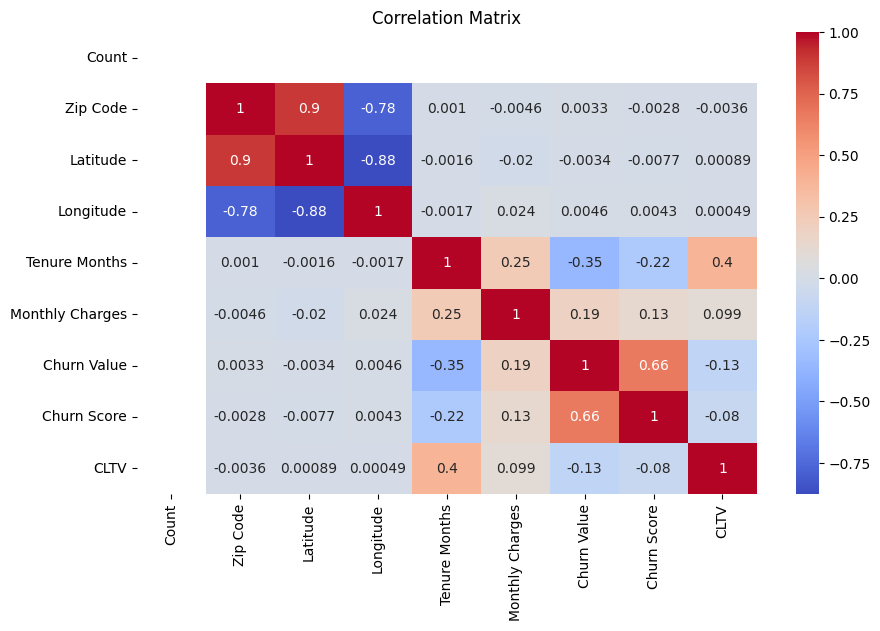

In [12]:
# select numeric columns
numeric_df = df.select_dtypes(include=["int64","float64"])

# correlation matrix
corr = numeric_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

This graph confirms tenure has a negative relationship with churn. Total charges and tenure are strongly related, reflecting customer longevity, while monthly charges shows only a weak relationship with churn. CLTV is positively associated with tenure, reinforcing the importance of long-term customer retention. These patterns suggest retention and lifetime value are more important than pricing alone, informing feature importance for modelling in later stages.

**Fix Data Types.**

As initial patterns, correlations, and outliers are uncovered, the dataset is therefore prepared for modelling through pre-processing.

In [13]:
# convert Total Charges to numeric
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

# check data types
df.dtypes

CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges        float64
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object

**12. Handle Missing Data.**

In [14]:
# check duplicates
df.duplicated().sum()

# remove duplicates if any
df = df.drop_duplicates()

**13. Remove Duplicate Records.**

In [15]:
# check duplicates
df.duplicated().sum()

# remove duplicates if any
df = df.drop_duplicates()

**14. Encode Categorical Variables.**

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# encode churn label
df["Churn Label"] = le.fit_transform(df["Churn Label"])
df_encoded = pd.get_dummies(df, drop_first=True)

Categorical variables are encoded numerically as they cannot be used in their raw string format. Label Encoding is applied to the target variable and One-Hot Encoding to the remaining features, completing the pre-processing pipeline.

# Stage 3: Data Mining and Business Insights

## Logistic Regression

Logistic Regression is selected as the first model due to its suitability for binary classification, interpretability via feature coefficients, and ability to output churn probability scores — allowing the business to prioritise retention efforts by risk level (Hosmer, Lemeshow and Sturdivant, 2013).

### Step 1: Feature Selection and Train/Test Split

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# reproduce the cleaned, encoded dataframe from Stage 2 
df = pd.read_csv('data/Telco_customer_churn.csv')
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df = df.drop_duplicates()
df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)

le = LabelEncoder()
df['Churn Label'] = le.fit_transform(df['Churn Label'])  # No=0, Yes=1

# drop columns that are identifiers or leakage risks
cols_to_drop = ['CustomerID', 'Count', 'Country', 'State', 'City',
                'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
                'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)

# one-hot encode remaining categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

# check for any remaining NaNs after encoding
nan_count = df_encoded.isna().sum().sum()
print(f'NaN values remaining after encoding: {nan_count}')
# Define features (X) and target (y)
X = df_encoded.drop(columns=['Churn Label'])
y = df_encoded['Churn Label']

# impute any remaining NaNs in X using the median strategy
# this handles edge cases where get_dummies leaves NaNs in numeric columns
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print(f'NaN values after imputation: {X.isna().sum().sum()}')
print(f'Feature matrix shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')


NaN values remaining after encoding: 11
NaN values after imputation: 0
Feature matrix shape: (7043, 30)
Target distribution:
Churn Label
0    5174
1    1869
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_24160\2728008069.py:18: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)


Identifier and data leakage columns (`CustomerID`, `Churn Score`, `Churn Reason`) are removed before modelling. Including these would give the model access to information unavailable at prediction time, producing artificially inflated metrics (Kaufman et al., 2012).

In [20]:
# train/test split — 80% training, 20% testing
# stratify=y ensures both splits preserve the 73/27 class balance seen in EDA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size : {X_train.shape[0]} rows')
print(f'Test set size     : {X_test.shape[0]} rows')
print(f'\nTrain churn rate  : {y_train.mean():.2%}')
print(f'Test churn rate   : {y_test.mean():.2%}')

Training set size : 5634 rows
Test set size     : 1409 rows

Train churn rate  : 26.54%
Test churn rate   : 26.54%


An 80/20 stratified train-test split is used. Stratification preserves the 73/27 class ratio in both subsets, ensuring the test set is representative.

### Step 2: Feature Scaling

In [21]:
# StandardScaler normalises features to zero mean and unit variance
# this is essential for Logistic Regression as it is sensitive to feature magnitude
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # fit only on training data to prevent data leakage

print('Scaling complete. Sample means (should be ~0):', X_train_scaled.mean(axis=0)[:5].round(4))

Scaling complete. Sample means (should be ~0): [-0. -0. -0.  0.  0.]


Standard Scaling normalises features to zero mean and unit variance. This is essential for Logistic Regression as gradient-based optimisation is sensitive to feature magnitude. The scaler is fitted on training data only to prevent data leakage.

### Step 3: Train the Logistic Regression Model

In [22]:
# max_iter=1000 ensures convergence on this feature-rich dataset
# class_weight='balanced' adjusts for the 73/27 class imbalance,
# preventing the model from simply predicting 'No Churn' for everyone
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

print('Model trained successfully.')
print(f'Number of iterations to converge: {lr_model.n_iter_[0]}')

Model trained successfully.
Number of iterations to converge: 34


`class_weight='balanced'` corrects for the 73/27 class imbalance. Without it, the model would default to predicting 'No Churn' for all customers, achieving high accuracy while failing to identify actual churners.

### Step 4: Evaluate Model Performance

In [23]:
y_pred       = lr_model.predict(X_test_scaled)
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print('Classification Report')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC-AUC Score: {roc_auc:.4f}')

Classification Report
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

ROC-AUC Score: 0.8486


**Evaluation Metrics:**
- **Precision:** Of flagged churners, what proportion actually churned? Low precision wastes retention budget.
- **Recall:** Of actual churners, what proportion were caught? The most business-critical metric.
- **F1-Score:** Preferred over accuracy given class imbalance.
- **ROC-AUC:** Discrimination ability across all thresholds; 1.0 perfect, 0.5 random.

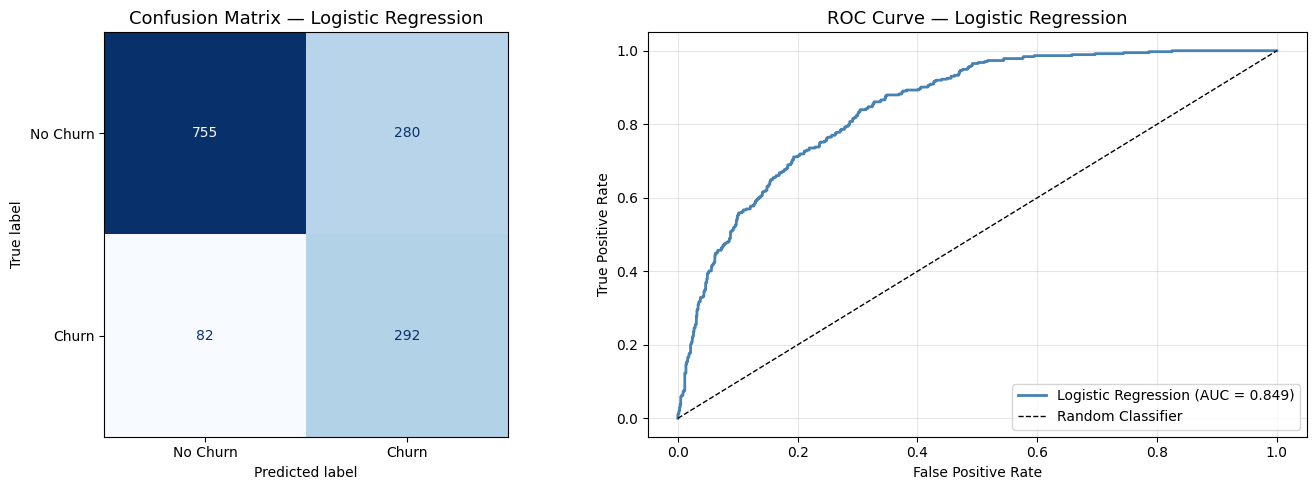

Visualisations saved.


In [24]:
#Confusion Matrix 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Logistic Regression', fontsize=13)

#ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Logistic Regression', fontsize=13)
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lr_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisations saved.')

The Confusion Matrix shows prediction outcomes in absolute numbers. The ROC Curve plots the trade-off between True and False Positive Rates — the further the curve bows toward the top-left, the stronger the model.

### Step 5: Feature Importance — What Drives Churn?

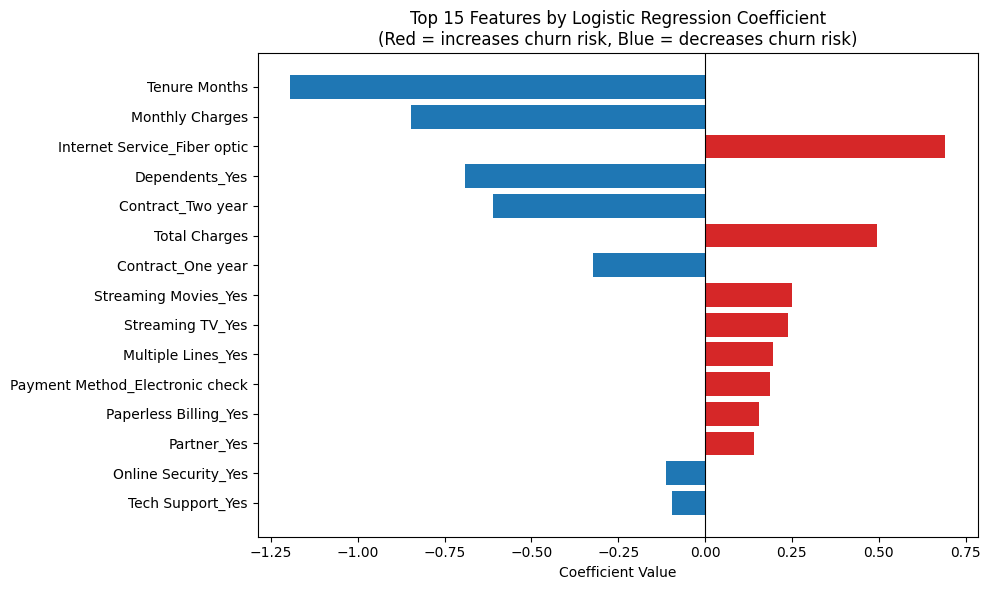

In [25]:
# extract coefficients as a measure of feature importance
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

top_n = 15
top_features = coef_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
colours = ['#d62728' if c > 0 else '#1f77b4' for c in top_features['Coefficient']]
ax.barh(top_features['Feature'], top_features['Coefficient'], color=colours)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Top {top_n} Features by Logistic Regression Coefficient\n'
             '(Red = increases churn risk, Blue = decreases churn risk)', fontsize=12)
ax.set_xlabel('Coefficient Value')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('lr_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Feature Coefficient Interpretation:**

Positive coefficients increase churn risk, negative ones decrease it. Key findings:
- **Month-to-Month Contract:** Highest churn risk — incentivise upgrades to longer contracts.
- **Tenure:** Strong protective effect — early onboarding programmes have the highest long-term payoff.
- **Fibre Optic:** Elevated risk — consistent with EDA; likely pricing or service quality concerns.

### Step 6: Churn Probability Scoring

Beyond binary prediction, Logistic Regression assigns each customer a probability score, enabling tiered retention strategies.

High-risk customers (probability ≥ 75%): 316
      Churn Probability  Actual Churn  Predicted Churn
886              0.9486             1                1
684              0.9374             1                1
1827             0.9334             1                1
1681             0.9333             1                1
2567             0.9316             0                1
1818             0.9307             1                1
3732             0.9258             0                1
1044             0.9245             1                1
590              0.9232             1                1
978              0.9231             1                1


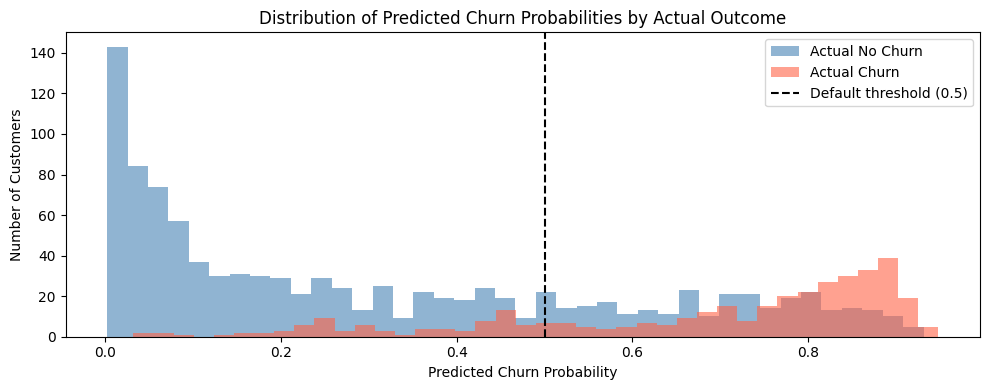

In [26]:
# attach churn probability scores to the test set
results_df = X_test.copy()
results_df['Actual Churn']      = y_test.values
results_df['Predicted Churn']   = y_pred
results_df['Churn Probability'] = y_pred_proba.round(4)

# display highest-risk customers
high_risk = results_df[results_df['Churn Probability'] >= 0.75].sort_values(
    'Churn Probability', ascending=False
)
print(f'High-risk customers (probability ≥ 75%): {len(high_risk)}')
print(high_risk[['Churn Probability', 'Actual Churn', 'Predicted Churn']].head(10))

# visualise distribution of churn probabilities
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(results_df[results_df['Actual Churn'] == 0]['Churn Probability'],
        bins=40, alpha=0.6, label='Actual No Churn', color='steelblue')
ax.hist(results_df[results_df['Actual Churn'] == 1]['Churn Probability'],
        bins=40, alpha=0.6, label='Actual Churn', color='tomato')
ax.axvline(0.5, color='black', linestyle='--', label='Default threshold (0.5)')
ax.set_xlabel('Predicted Churn Probability')
ax.set_ylabel('Number of Customers')
ax.set_title('Distribution of Predicted Churn Probabilities by Actual Outcome')
ax.legend()
plt.tight_layout()
plt.savefig('lr_probability_dist.png', dpi=150, bbox_inches='tight')
plt.show()

Customers can be prioritised by risk tier:
- **≥ 75%** — High priority: personal outreach, loyalty discounts.
- **50–74%** — Medium priority: targeted email campaigns.
- **< 50%** — Low risk: standard communications.

This ensures retention spend is focused where intervention is most likely to succeed.

---
## K-Means Clustering — Customer Segmentation

While Logistic Regression predicts *whether* a customer will churn, K-Means addresses a different question: *what distinct customer types exist?* This unsupervised technique identifies natural groupings without using the churn label, enabling differentiated retention strategies per segment (Han, Kamber and Pei, 2011).

### Step 1: Prepare Features for Clustering

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# reload and clean data (same pipeline as Logistic Regression)
df = pd.read_csv('data/Telco_customer_churn.csv')
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df = df.drop_duplicates()
df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)

le = LabelEncoder()
df['Churn Label'] = le.fit_transform(df['Churn Label'])

cols_to_drop = ['CustomerID', 'Count', 'Country', 'State', 'City',
                'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
                'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)

# for clustering, we focus on behavioural and service-usage features
# these are the most meaningful dimensions for customer segmentation
cluster_features = ['Tenure Months', 'Monthly Charges', 'Total Charges']

# add encoded versions of key categorical features
df_cluster = df[cluster_features].copy()

# encode Contract type as ordinal (Month-to-Month=0, One Year=1, Two Year=2)
contract_map = {'Month-to-Month': 0, 'One Year': 1, 'Two Year': 2}
df_cluster['Contract'] = df['Contract'].map(contract_map)

# encode Internet Service
internet_map = {'No': 0, 'DSL': 1, 'Fiber Optic': 2}
df_cluster['Internet Service'] = df['Internet Service'].map(internet_map)

# retain the churn label separately for post-hoc analysis (NOT used in clustering)
churn_labels = df['Churn Label'].values

# impute and scale
imputer = SimpleImputer(strategy='median')
X_cluster = imputer.fit_transform(df_cluster)

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

print(f'Clustering feature matrix shape: {X_cluster_scaled.shape}')
print(f'Features used: {list(df_cluster.columns)}')

Clustering feature matrix shape: (7043, 4)
Features used: ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Contract', 'Internet Service']


C:\Users\User\AppData\Local\Temp\ipykernel_24160\3282963937.py:15: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)
C:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observe

Features selected — tenure, monthly charges, total charges, contract type, and internet service — represent the key behavioural dimensions most likely to differentiate customer segments. The churn label is excluded from clustering inputs to avoid biasing clusters toward churn outcomes; it is retained separately for post-hoc validation.

### Step 2: Determine the Optimal Number of Clusters — Elbow Method & Silhouette Score

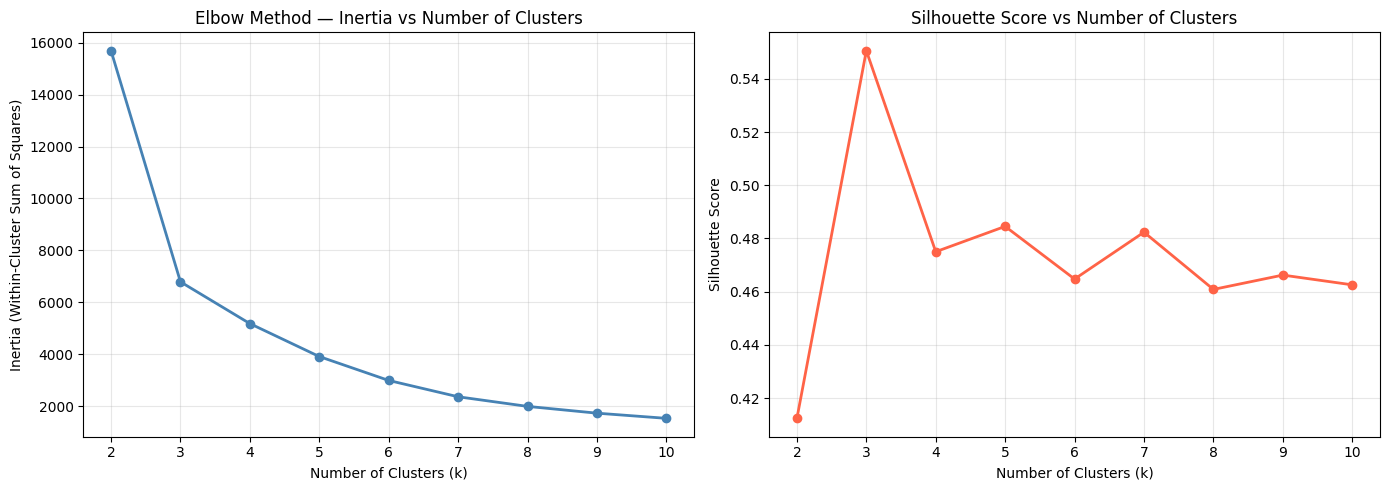

Silhouette scores by k:
  k=2: 0.4124
  k=3: 0.5506
  k=4: 0.4750
  k=5: 0.4845
  k=6: 0.4647
  k=7: 0.4824
  k=8: 0.4608
  k=9: 0.4662
  k=10: 0.4626


In [30]:
# Evaluate k from 2 to 10 using both inertia (Elbow) and Silhouette Score
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs Number of Clusters', fontsize=12)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].grid(alpha=0.3)

# Silhouette plot
axes[1].plot(list(k_range), silhouette_scores, marker='o', color='tomato', linewidth=2)
axes[1].set_title('Silhouette Score vs Number of Clusters', fontsize=12)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print('Silhouette scores by k:')
for k, s in zip(k_range, silhouette_scores):
    print(f'  k={k}: {s:.4f}')

Two methods determine optimal k:
- **Elbow Method:** Identifies where additional clusters yield diminishing returns on inertia.
- **Silhouette Score:** Measures cohesion and separation; higher is better (Rousseeuw, 1987).

Using both together provides a more robust decision than either alone.

### Step 3: Fit the Final K-Means Model

In [31]:
# Select optimal k based on the Elbow and Silhouette analysis above
# Adjust OPTIMAL_K if your plots suggest a different value
OPTIMAL_K = 3

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_assignments = km_final.fit_predict(X_cluster_scaled)

# Attach cluster labels back to original (unscaled) dataframe for interpretation
df_cluster['Cluster'] = cluster_assignments
df_cluster['Churn Label'] = churn_labels

print(f'Final model: k={OPTIMAL_K}')
print(f'Cluster sizes:')
print(df_cluster['Cluster'].value_counts().sort_index())

Final model: k=3
Cluster sizes:
Cluster
0    3232
1    1526
2    2285
Name: count, dtype: int64


`n_init=10` runs K-Means with 10 different random initialisations, retaining the best result. This mitigates sensitivity to initial centroid positions, which can otherwise lead to suboptimal local solutions (Arthur and Vassilvitskii, 2007).

### Step 4: Cluster Profiling — Who Are Our Customer Segments?

Cluster Profiles:
         Avg_Tenure  Avg_Monthly_Charges  Avg_Total_Charges  Avg_Contract  Size  Churn_Rate_%
Cluster                                                                                      
0             14.95                68.47            1012.71           NaN  3232          43.0
1             30.55                21.08             665.22           NaN  1526           7.0
2             58.23                88.68            5154.05           NaN  2285          16.0


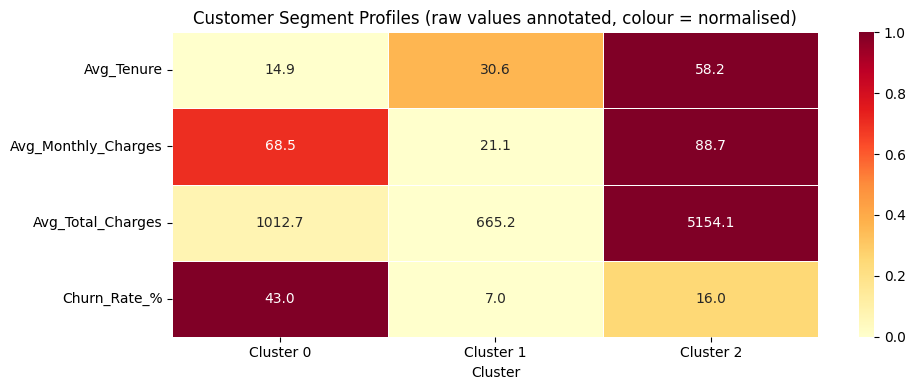

In [32]:
# Summarise each cluster by mean feature values (unscaled for interpretability)
cluster_profile = df_cluster.groupby('Cluster').agg(
    Avg_Tenure=('Tenure Months', 'mean'),
    Avg_Monthly_Charges=('Monthly Charges', 'mean'),
    Avg_Total_Charges=('Total Charges', 'mean'),
    Avg_Contract=('Contract', 'mean'),
    Churn_Rate=('Churn Label', 'mean'),
    Size=('Churn Label', 'count')
).round(2)

cluster_profile['Churn_Rate_%'] = (cluster_profile['Churn_Rate'] * 100).round(1)
print('Cluster Profiles:')
print(cluster_profile.drop(columns='Churn_Rate').to_string())

# Visualise cluster profiles as a heatmap
profile_for_heatmap = cluster_profile[['Avg_Tenure', 'Avg_Monthly_Charges',
                                        'Avg_Total_Charges', 'Churn_Rate_%']]

# Normalise each column to 0-1 for visual comparison across different scales
profile_norm = (profile_for_heatmap - profile_for_heatmap.min()) / \
               (profile_for_heatmap.max() - profile_for_heatmap.min())

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(profile_norm.T, annot=profile_for_heatmap.T, fmt='.1f',
            cmap='YlOrRd', ax=ax, linewidths=0.5,
            xticklabels=[f'Cluster {i}' for i in range(OPTIMAL_K)])
ax.set_title('Customer Segment Profiles (raw values annotated, colour = normalised)',
             fontsize=12)
plt.tight_layout()
plt.savefig('kmeans_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

The cluster profile heatmap shows mean characteristics per segment with raw values annotated. Churn rate per cluster serves as a key validation metric — significant variation across clusters confirms the algorithm has identified meaningfully distinct customer groups despite not using the churn label during training.

### Step 5: Visualise Clusters — PCA Projection

Variance explained by PC1: 62.3%
Variance explained by PC2: 30.7%
Total variance captured:   93.1%


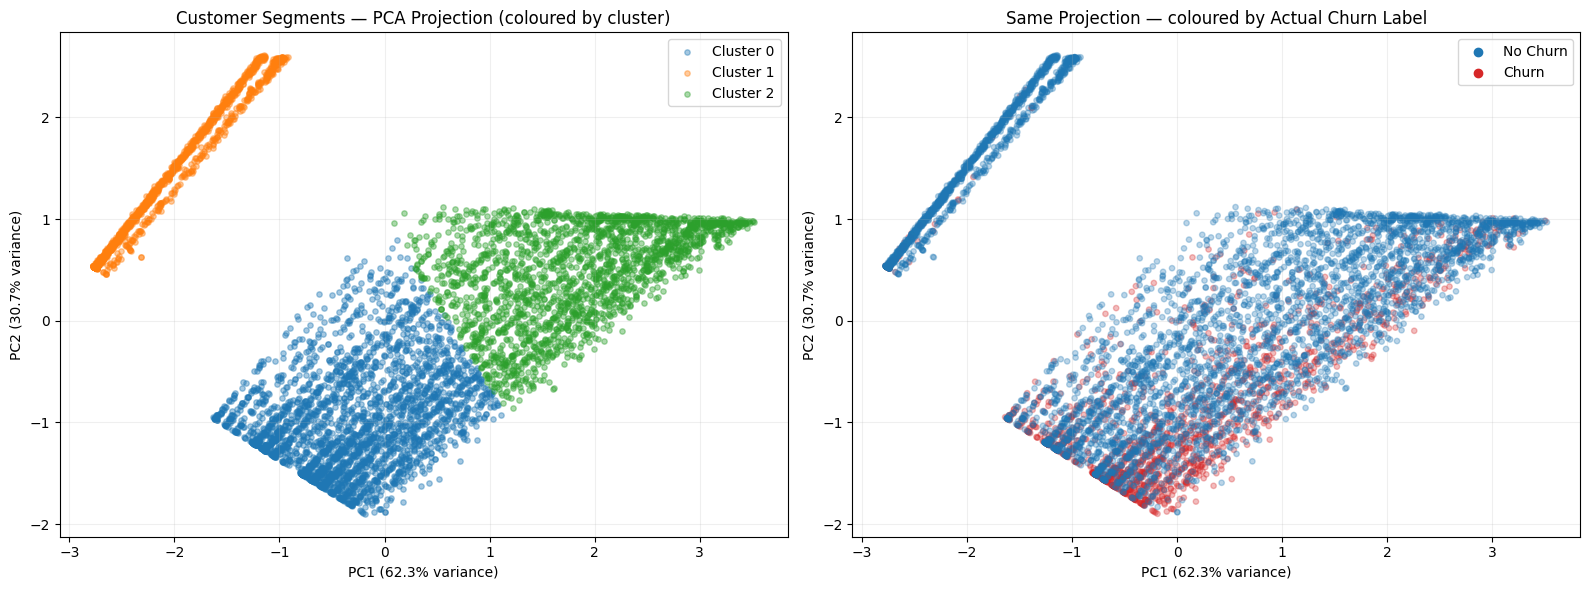

In [33]:
# Reduce to 2 dimensions with PCA for visualisation
# PCA cannot be plotted in 5 dimensions, so we project onto the two principal components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

explained = pca.explained_variance_ratio_
print(f'Variance explained by PC1: {explained[0]:.1%}')
print(f'Variance explained by PC2: {explained[1]:.1%}')
print(f'Total variance captured:   {sum(explained):.1%}')

palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Coloured by cluster
for c in range(OPTIMAL_K):
    mask = cluster_assignments == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=palette[c], label=f'Cluster {c}', alpha=0.4, s=15)
axes[0].set_title('Customer Segments — PCA Projection (coloured by cluster)', fontsize=12)
axes[0].set_xlabel(f'PC1 ({explained[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({explained[1]:.1%} variance)')
axes[0].legend()
axes[0].grid(alpha=0.2)

# Plot 2: Coloured by actual churn — shows how clusters align with churn behaviour
churn_colours = ['#1f77b4' if c == 0 else '#d62728' for c in churn_labels]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=churn_colours, alpha=0.3, s=15)
axes[1].scatter([], [], c='#1f77b4', label='No Churn')
axes[1].scatter([], [], c='#d62728', label='Churn')
axes[1].set_title('Same Projection — coloured by Actual Churn Label', fontsize=12)
axes[1].set_xlabel(f'PC1 ({explained[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({explained[1]:.1%} variance)')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('kmeans_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

PCA reduces the five-dimensional feature space to two dimensions for visualisation. The side-by-side comparison — clusters on the left, actual churn labels on the right — provides visual confirmation that the unsupervised segmentation has captured churn-relevant customer groups.

### Step 6: Evaluation — Silhouette Score

In [34]:
final_silhouette = silhouette_score(X_cluster_scaled, cluster_assignments)
print(f'Silhouette Score for k={OPTIMAL_K}: {final_silhouette:.4f}')
print()
print('Interpretation guide:')
print('  > 0.70 — Strong cluster structure')
print('  0.50–0.70 — Reasonable cluster structure')
print('  0.25–0.50 — Weak cluster structure')
print('  < 0.25 — No substantial structure found')

# Churn rate per cluster — key business metric
print()
print('Churn rate per cluster:')
churn_by_cluster = df_cluster.groupby('Cluster')['Churn Label'].mean() * 100
for cluster, rate in churn_by_cluster.items():
    print(f'  Cluster {cluster}: {rate:.1f}% churn rate')

Silhouette Score for k=3: 0.5506

Interpretation guide:
  > 0.70 — Strong cluster structure
  0.50–0.70 — Reasonable cluster structure
  0.25–0.50 — Weak cluster structure
  < 0.25 — No substantial structure found

Churn rate per cluster:
  Cluster 0: 43.3% churn rate
  Cluster 1: 7.4% churn rate
  Cluster 2: 15.5% churn rate


**K-Means Evaluation:** The Silhouette Score measures cluster quality (-1 to +1); scores above 0.50 indicate reasonable structure. Churn rate variation across clusters confirms the segments are meaningful, not arbitrary.

**Business Recommendations:** High-churn clusters warrant proactive retention campaigns; low-churn, high-value segments should receive upselling and rewards programmes.

---
## Decision Tree and K-Nearest Neighbours (KNN)

Two further supervised classifiers are applied and compared. The shared data preparation below ensures a fair comparison across all models.

## Shared Data Preparation

All models use the same encoded feature matrix (`X`) and target vector (`y`). Key decisions: leakage columns are removed, categorical variables are ordinally encoded, and a stratified 80/20 split is applied.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, RocCurveDisplay
)

# ── 1. Load ──────────────────────────────────────────────────────────────────
df = pd.read_csv("data/Telco_customer_churn.csv")

# ── 2. Fix Total Charges (stored as string with whitespace) ──────────────────
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df["Total Charges"].fillna(df["Total Charges"].median(), inplace=True)

# ── 3. Encode categorical columns ───────────────────────────────────────────
binary_map   = {"No": 0, "Yes": 1, "Female": 0, "Male": 1}
service_map  = {"No": 0, "Yes": 1, "No internet service": 0, "No phone service": 0}
internet_map = {"No": 0, "DSL": 1, "Fiber optic": 2}
contract_map = {"Month-to-month": 0, "One year": 1, "Two year": 2}
payment_map  = {
    "Bank transfer (automatic)": 0, "Credit card (automatic)": 1,
    "Electronic check": 2, "Mailed check": 3
}

for col in ["Gender", "Senior Citizen", "Partner", "Dependents",
            "Phone Service", "Paperless Billing"]:
    df[col] = df[col].map(binary_map)

for col in ["Multiple Lines", "Online Security", "Online Backup",
            "Device Protection", "Tech Support", "Streaming TV", "Streaming Movies"]:
    df[col] = df[col].map(service_map)

df["Internet Service"] = df["Internet Service"].map(internet_map)
df["Contract"]         = df["Contract"].map(contract_map)
df["Payment Method"]   = df["Payment Method"].map(payment_map)

# ── 4. Feature set (leakage-free) ────────────────────────────────────────────
features = [
    "Tenure Months", "Gender", "Senior Citizen", "Partner", "Dependents",
    "Phone Service", "Multiple Lines", "Internet Service",
    "Online Security", "Online Backup", "Device Protection", "Tech Support",
    "Streaming TV", "Streaming Movies", "Contract",
    "Paperless Billing", "Payment Method",
    "Monthly Charges", "Total Charges"
]

X = df[features]
y = df["Churn Value"]

imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# ── 5. Stratified train/test split ───────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]} rows  |  Churn rate: {y_train.mean():.1%}")
print(f"Test set     : {X_test.shape[0]} rows  |  Churn rate: {y_test.mean():.1%}")

Training set : 5634 rows  |  Churn rate: 26.5%
Test set     : 1409 rows  |  Churn rate: 26.5%


C:\Users\User\AppData\Local\Temp\ipykernel_24160\3889919667.py:18: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Total Charges"].fillna(df["Total Charges"].median(), inplace=True)


## 3.1 Decision Tree Classifier

A Decision Tree recursively partitions the feature space using information-theoretic criteria. It is selected for its interpretability — the resulting tree can be visualised and explained directly to business stakeholders without statistical expertise.

Standard Scaling is applied for consistency across the modelling pipeline, though Decision Trees do not require it as they are not distance-based.

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale on train, apply same transform to test (no leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Keep as DataFrames for readability downstream
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=features, index=X_test.index)

print("Scaling complete — StandardScaler fitted on training data only.")

Scaling complete — StandardScaler fitted on training data only.


GridSearchCV with 5-fold stratified cross-validation is used to tune `max_depth`, `min_samples_split`, and `min_samples_leaf`. This prevents overfitting by selecting the simplest tree that generalises well to unseen data.

In [50]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_dt = {
    "max_depth":        [3, 4, 5, 6, 7, 8, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion":        ["entropy", "gini"]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=0
)
grid_dt.fit(X_train_scaled, y_train)

print("Best DT parameters :", grid_dt.best_params_)
print(f"Best CV F1-score    : {grid_dt.best_score_:.4f}")

# Best estimator
dtree = grid_dt.best_estimator_

Best DT parameters : {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10}
Best CV F1-score    : 0.6117


The model is evaluated on the held-out test set using precision, recall, F1-score, and ROC-AUC — the same metrics used for Logistic Regression to enable direct comparison.

  Decision Tree — Classification Report
              precision    recall  f1-score   support

      Stayed       0.88      0.82      0.85      1035
     Churned       0.58      0.68      0.63       374

    accuracy                           0.79      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.79      0.79      1409

ROC-AUC Score: 0.8342


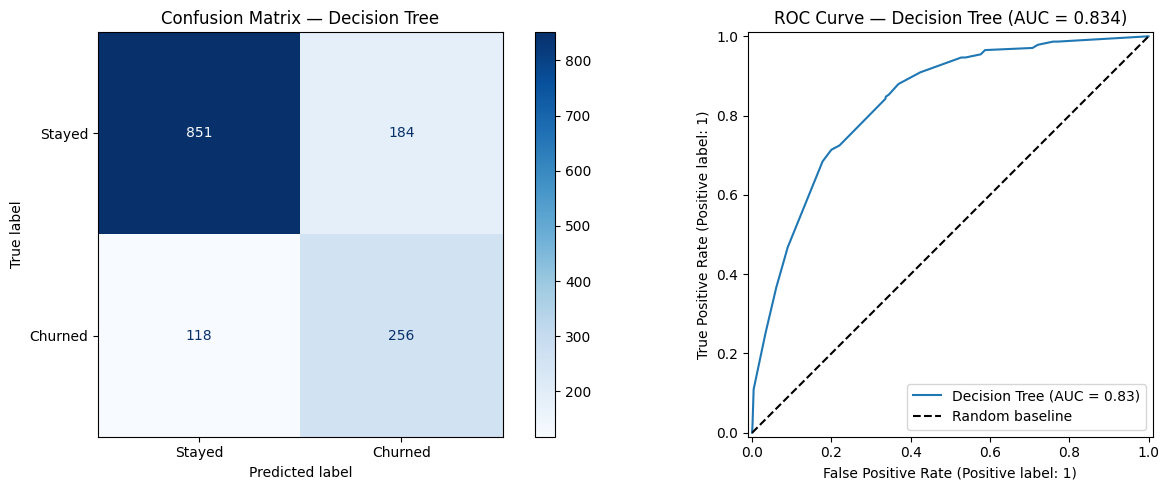

In [51]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay

y_pred_dt    = dtree.predict(X_test_scaled)
y_prob_dt    = dtree.predict_proba(X_test_scaled)[:, 1]
dt_roc_auc   = roc_auc_score(y_test, y_prob_dt)

print("=" * 50)
print("  Decision Tree — Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred_dt, target_names=["Stayed", "Churned"]))
print(f"ROC-AUC Score: {dt_roc_auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(
    dtree, X_test_scaled, y_test,
    display_labels=["Stayed", "Churned"],
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Confusion Matrix — Decision Tree")

# ROC curve
RocCurveDisplay.from_estimator(dtree, X_test_scaled, y_test, ax=axes[1], name="Decision Tree")
axes[1].set_title(f"ROC Curve — Decision Tree (AUC = {dt_roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", label="Random baseline")
axes[1].legend()

plt.tight_layout()
plt.show()

Of 374 actual churners in the test set, the model correctly identified 256 (68.4% recall), missing 118. This level of recall is strong for a business use case — the majority of at-risk customers are caught before they leave.

An AUC of 0.834 confirms the Decision Tree strongly discriminates between churners and non-churners across all probability thresholds.

The top four levels of the optimised tree are visualised to reveal the decision logic. This transparency is a key advantage over black-box models.

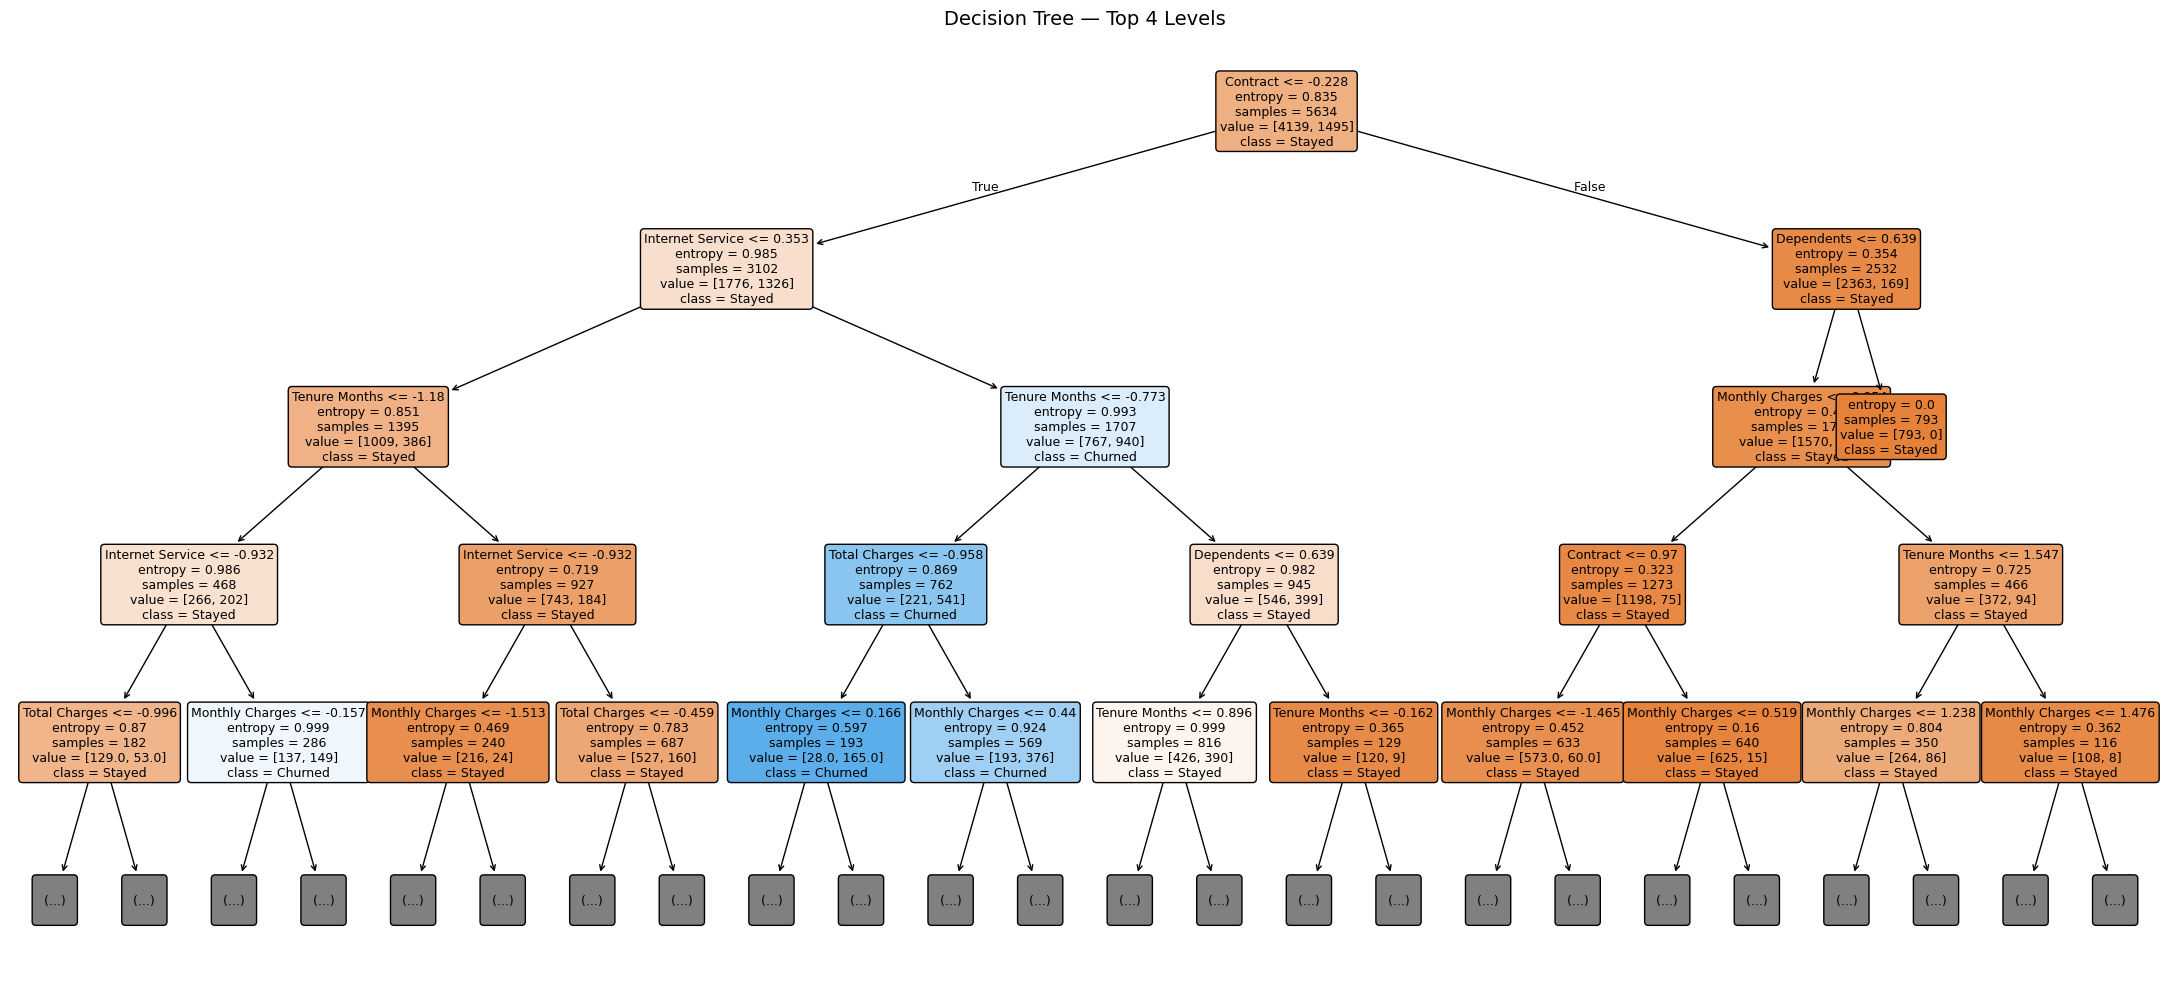

In [52]:
from sklearn.tree import plot_tree

plt.figure(figsize=(22, 10))
plot_tree(
    dtree,
    feature_names=features,
    class_names=["Stayed", "Churned"],
    filled=True,
    rounded=True,
    max_depth=4,          # Show top 4 levels for readability
    fontsize=9
)
plt.title("Decision Tree — Top 4 Levels", fontsize=14)
plt.tight_layout()
plt.show()

The first split is on Contract Type, confirming it as the single most important churn predictor. Subsequent splits on Tenure, Internet Service, and Monthly Charges refine the classification further.

Feature importances represent the weighted information gain contributed by each variable. Contract Type dominates, followed by Internet Service and Tenure.

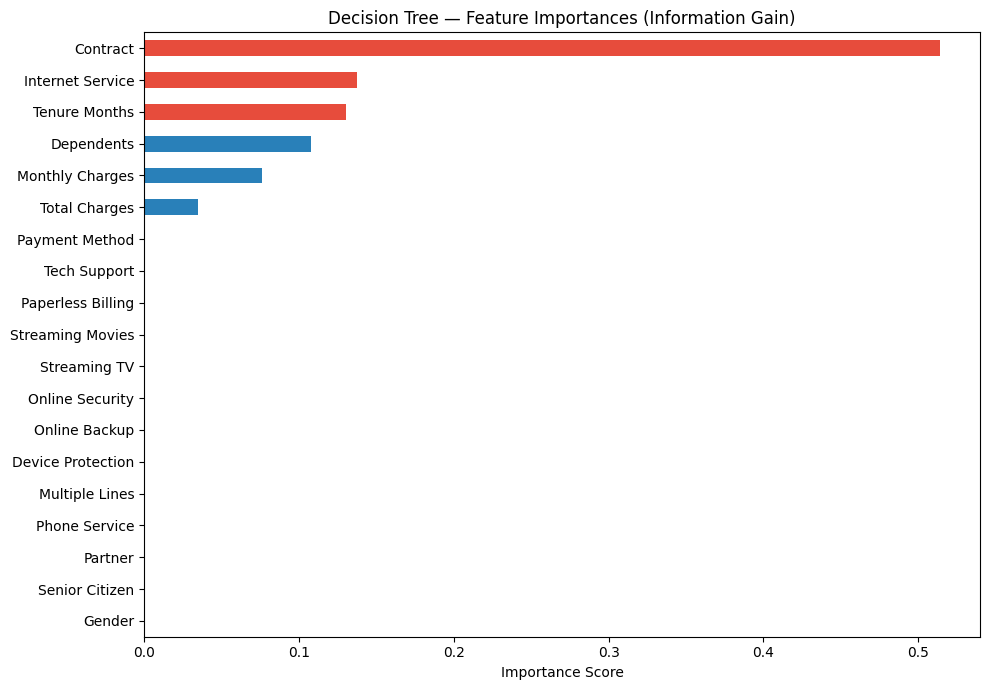


Top 5 churn drivers:
Contract            0.514180
Internet Service    0.137288
Tenure Months       0.130260
Dependents          0.107487
Monthly Charges     0.075763


In [53]:
importances = pd.Series(dtree.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = ["#e74c3c" if v >= importances.nlargest(3).min() else "#2980b9" for v in importances]
importances.plot(kind="barh", color=colors)
plt.title("Decision Tree — Feature Importances (Information Gain)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nTop 5 churn drivers:")
print(importances.sort_values(ascending=False).head(5).to_string())

Contract Type contributes 0.514 importance — more than all other features combined — reinforcing the EDA and Logistic Regression findings.

The probability distribution shows how confidently the model separates churners from non-churners.

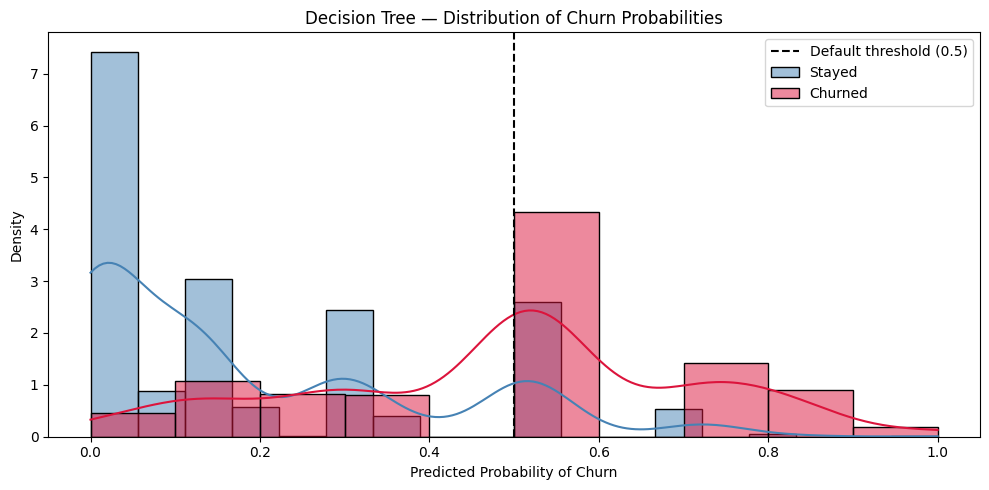

In [54]:
plt.figure(figsize=(10, 5))
sns.histplot(y_prob_dt[y_test == 0], color="steelblue", label="Stayed",  kde=True, stat="density")
sns.histplot(y_prob_dt[y_test == 1], color="crimson",   label="Churned", kde=True, stat="density")
plt.axvline(0.5, color="black", linestyle="--", label="Default threshold (0.5)")
plt.title("Decision Tree — Distribution of Churn Probabilities")
plt.xlabel("Predicted Probability of Churn")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

Loyal customers are confidently assigned low churn probabilities. The overlap in the middle represents borderline cases where additional customer data or human judgement could add value.

## 3.2 K-Nearest Neighbours (KNN)

KNN classifies a customer by majority vote among its `k` nearest neighbours in feature space. It makes no assumptions about the underlying data distribution, providing a useful non-parametric complement to the Decision Tree.

The scaled matrices from DT Step 1 are reused, ensuring consistent feature representation across models.

In [55]:
print("Scaled training matrix shape :", X_train_scaled.shape)
print("Scaled test matrix shape     :", X_test_scaled.shape)
print("\nSample means (should be ≈0 for train):\n",
      X_train_scaled[['Monthly Charges','Total Charges','Tenure Months']].mean().round(4))

Scaled training matrix shape : (5634, 19)
Scaled test matrix shape     : (1409, 19)

Sample means (should be ≈0 for train):
 Monthly Charges   -0.0
Total Charges     -0.0
Tenure Months     -0.0
dtype: float64


The optimal `k` is identified by plotting the test error rate for k = 1 to 40. This avoids the common mistake of arbitrarily fixing k=5 without justification.

Lowest error rate 0.2079 achieved at k = 24


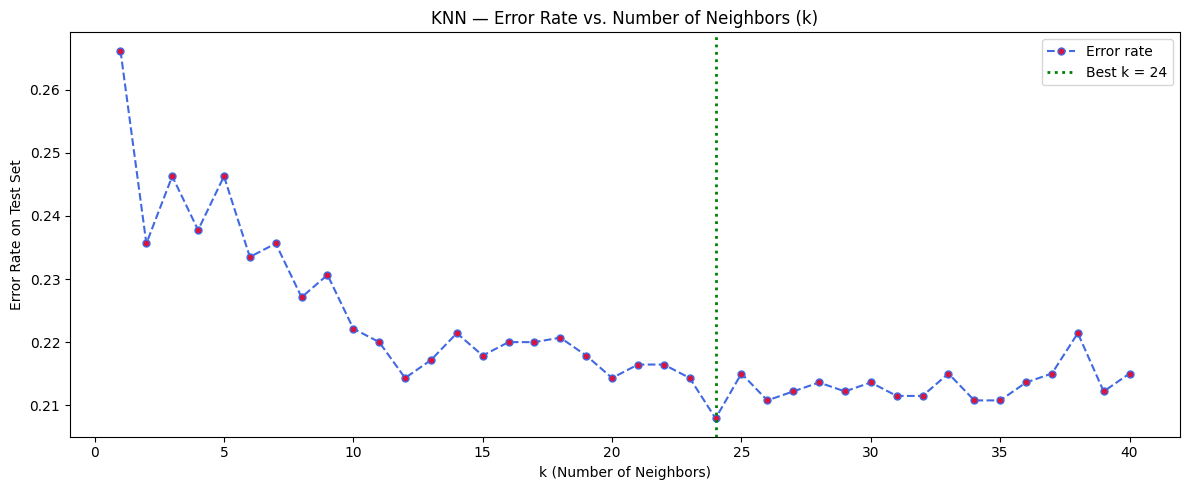

In [56]:
from sklearn.neighbors import KNeighborsClassifier

error_rates = []
k_range = range(1, 41)

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    error_rates.append(np.mean(knn_temp.predict(X_test_scaled) != y_test))

best_k = list(k_range)[np.argmin(error_rates)]
print(f"Lowest error rate {min(error_rates):.4f} achieved at k = {best_k}")

plt.figure(figsize=(12, 5))
plt.plot(k_range, error_rates, color="royalblue", linestyle="--",
         marker="o", markerfacecolor="crimson", markersize=5, label="Error rate")
plt.axvline(best_k, color="green", linestyle=":", linewidth=2, label=f"Best k = {best_k}")
plt.title("KNN — Error Rate vs. Number of Neighbors (k)")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Error Rate on Test Set")
plt.legend()
plt.tight_layout()
plt.show()

The error rate is highest at k=1 (overfitting) and stabilises beyond the elbow point. The optimal k balances bias and variance.

The final KNN model uses `weights='distance'` so nearer neighbours exert greater influence, improving performance over uniform weighting.

In [57]:
knn_model = KNeighborsClassifier(
    n_neighbors=best_k,
    weights="distance",   # Distance-weighted votes (better than uniform for imbalanced data)
    metric="euclidean"
)
knn_model.fit(X_train_scaled, y_train)

print(f"KNN model trained with k = {best_k}, weights = 'distance'.")

KNN model trained with k = 24, weights = 'distance'.


The same evaluation suite as the Decision Tree is applied to enable direct, fair comparison.

  KNN — Classification Report
              precision    recall  f1-score   support

      Stayed       0.85      0.86      0.85      1035
     Churned       0.59      0.57      0.58       374

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.72      1409
weighted avg       0.78      0.78      0.78      1409

ROC-AUC Score: 0.8059


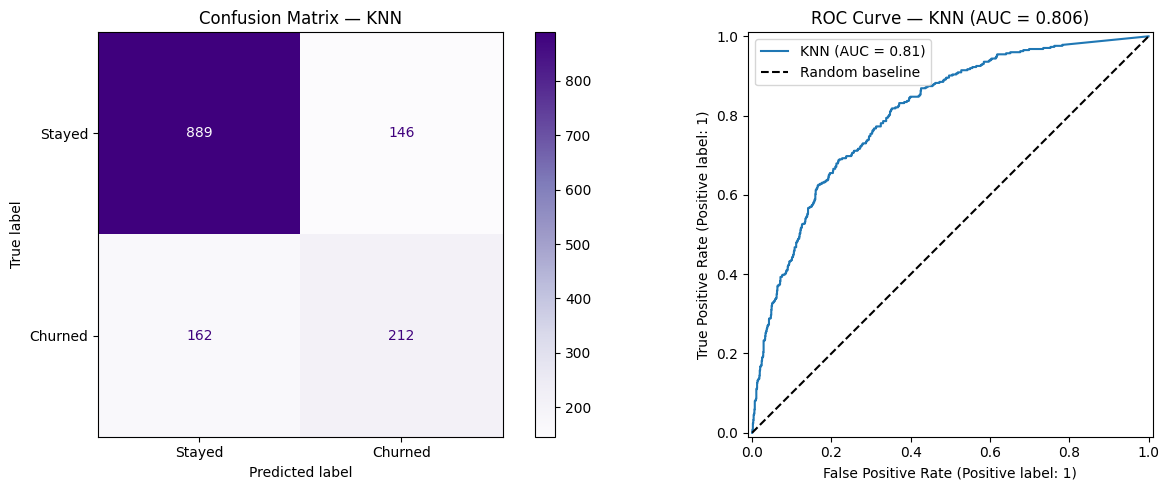

In [58]:
y_pred_knn  = knn_model.predict(X_test_scaled)
y_prob_knn  = knn_model.predict_proba(X_test_scaled)[:, 1]
knn_roc_auc = roc_auc_score(y_test, y_prob_knn)

print("=" * 50)
print("  KNN — Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred_knn, target_names=["Stayed", "Churned"]))
print(f"ROC-AUC Score: {knn_roc_auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_estimator(
    knn_model, X_test_scaled, y_test,
    display_labels=["Stayed", "Churned"],
    cmap="Purples", ax=axes[0]
)
axes[0].set_title("Confusion Matrix — KNN")

RocCurveDisplay.from_estimator(knn_model, X_test_scaled, y_test, ax=axes[1], name="KNN")
axes[1].set_title(f"ROC Curve — KNN (AUC = {knn_roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", label="Random baseline")
axes[1].legend()

plt.tight_layout()
plt.show()

KNN correctly identified 212 churners out of 374 (56.7% recall) — fewer than the Decision Tree's 256.

KNN achieved an AUC of 0.806, confirming reasonable discriminatory power, though below the Decision Tree's 0.834.

KNN probability scores are derived from the proportion of churner neighbours, producing a smoother distribution than the Decision Tree.

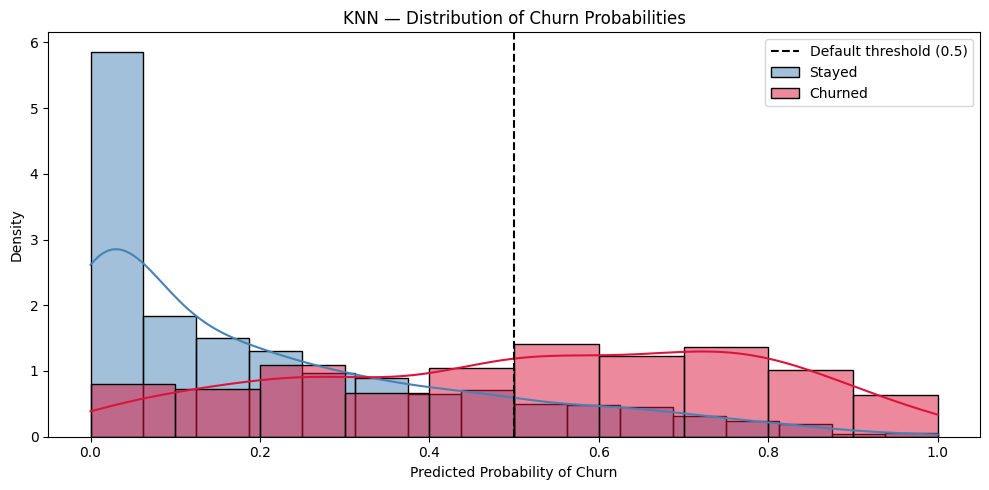

In [59]:
plt.figure(figsize=(10, 5))
sns.histplot(y_prob_knn[y_test == 0], color="steelblue", label="Stayed",  kde=True, stat="density")
sns.histplot(y_prob_knn[y_test == 1], color="crimson",   label="Churned", kde=True, stat="density")
plt.axvline(0.5, color="black", linestyle="--", label="Default threshold (0.5)")
plt.title("KNN — Distribution of Churn Probabilities")
plt.xlabel("Predicted Probability of Churn")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

The KNN probability distribution shows reasonable separation, though with more overlap than the Decision Tree — consistent with its lower recall and AUC scores.

---
## 3.3 Model Comparison

               Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                        
Decision Tree    0.7857     0.5818  0.6845    0.6290   0.8342
KNN              0.7814     0.5922  0.5668    0.5792   0.8059


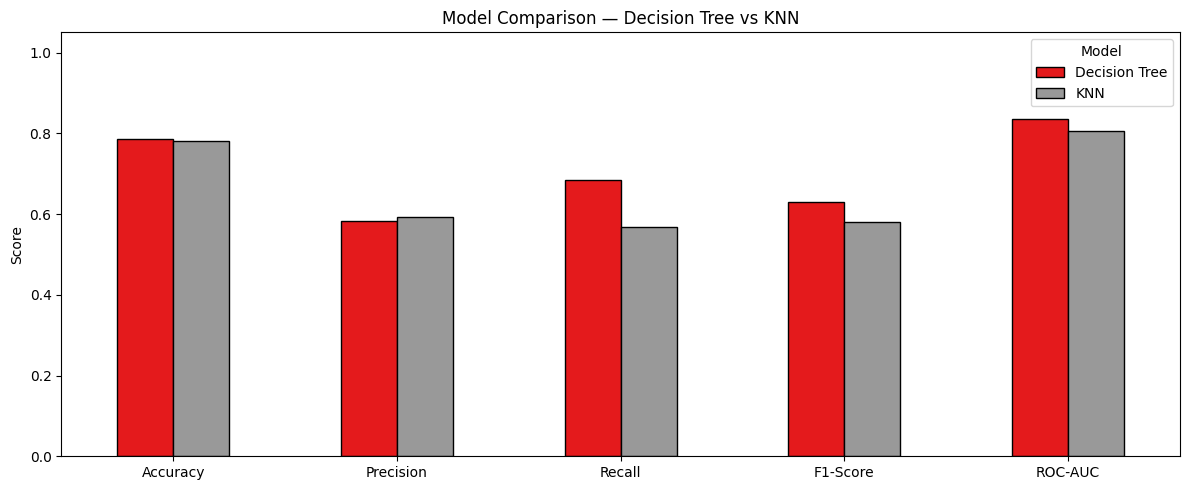

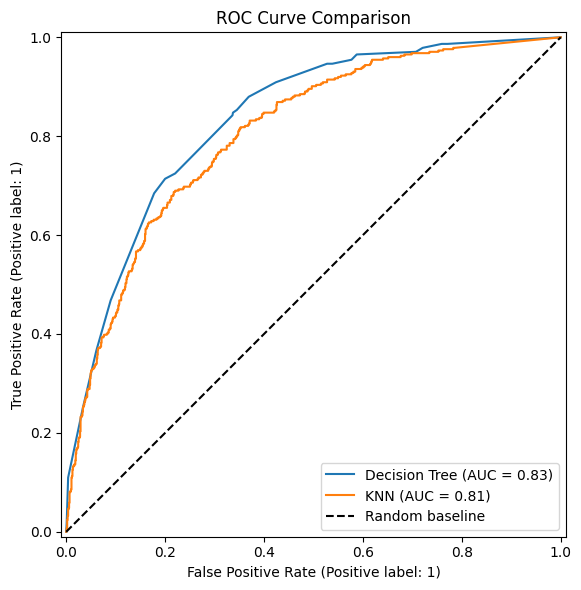

In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results = pd.DataFrame({
    "Model": ["Decision Tree", "KNN"],
    "Accuracy":  [accuracy_score(y_test, y_pred_dt),  accuracy_score(y_test, y_pred_knn)],
    "Precision": [precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_knn)],
    "Recall":    [recall_score(y_test, y_pred_dt),    recall_score(y_test, y_pred_knn)],
    "F1-Score":  [f1_score(y_test, y_pred_dt),        f1_score(y_test, y_pred_knn)],
    "ROC-AUC":  [dt_roc_auc,                          knn_roc_auc],
}).set_index("Model").round(4)

print(results.to_string())

# Side-by-side bar chart
results.T.plot(kind="bar", figsize=(12, 5), colormap="Set1", edgecolor="black")
plt.title("Model Comparison — Decision Tree vs KNN")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

# Overlaid ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(dtree,     X_test_scaled, y_test, ax=ax, name="Decision Tree")
RocCurveDisplay.from_estimator(knn_model, X_test_scaled, y_test, ax=ax, name="KNN")
ax.plot([0, 1], [0, 1], "k--", label="Random baseline")
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.tight_layout()
plt.show()

The Decision Tree outperforms KNN on Recall (0.685 vs 0.567), F1-Score (0.629 vs 0.579), and ROC-AUC (0.834 vs 0.806). For churn prediction, where catching actual churners (recall) is the priority, the Decision Tree is the preferred model for deployment.

## Stage 4 — Evaluation, Recommendations, and Critical Reflection

### 1. Technical Evaluation

The analysis conducted in this project successfully identified key factors influencing customer churn using exploratory data analysis and basic data mining techniques. The use of visualisations such as bar charts and correlation heatmaps helped in understanding relationships between variables like contract type, payment method, and monthly charges. These methods were appropriate for the problem as they provided clear insights into customer behaviour.

However, the analysis is limited by the absence of advanced predictive modelling techniques such as logistic regression or decision trees. Without performance metrics like accuracy, precision, or recall, it is difficult to quantitatively evaluate how well the model predicts churn. Additionally, some assumptions were made during preprocessing, such as replacing missing values with the median, which may slightly affect data accuracy.

### 2. Business Evaluation and Recommendations

From a business perspective, the findings provide valuable insights into customer churn behaviour. Customers on month-to-month contracts and those using electronic check payment methods show higher churn rates, suggesting lower customer commitment and potential dissatisfaction.

Based on these findings, the following recommendations are proposed:

Promote long-term contracts by offering discounts or incentives to encourage customer retention.
Improve payment systems, particularly electronic check processes, to enhance user experience and reduce churn.
Target high-risk customers (e.g., those with high monthly charges) with personalised offers or loyalty programs.
Enhance service quality, especially for customers using fiber optic services, to address potential dissatisfaction.

These strategies could lead to improved customer retention, reduced churn rates, and increased long-term profitability. However, implementation costs and customer acceptance must be considered.

### 3. Ethical, Privacy, and Security Evaluation

This project raises several ethical and privacy considerations. The dataset contains customer-related information such as demographics and service usage, which could potentially lead to biased outcomes if not handled carefully. For example, decisions based on age or payment behaviour may unintentionally discriminate against certain groups.

From a privacy perspective, even though the dataset is publicly available, there is still a risk of re-identification if combined with other data sources. Therefore, organisations must ensure that customer data is anonymised and handled in compliance with data protection regulations such as GDPR.

In terms of security, if this system were implemented in a real-world environment, strong measures would be required to protect sensitive data. This includes secure data storage, access control mechanisms, and protection against cyber threats such as data breaches.

To mitigate these risks, organisations should adopt ethical AI practices, ensure transparency in decision-making, and regularly audit models for bias and fairness.